# K-Nearest Neighbors (KNN) Classification

In this notebook, we'll implement a K-Nearest Neighbors classifier using the Classified Data dataset. We'll go through the following steps:

1. Data Loading and Exploration
2. Data Preprocessing
3. Model Training
4. Model Evaluation
5. Making Predictions

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Explore the Data

In [2]:
# Load the dataset
df = pd.read_csv('Classified Data')

# Display the first few rows and basic information
print("First few rows of the dataset:")
print(df.head())
print("\nDataset information:")
print(df.info())

First few rows of the dataset:
   Unnamed: 0       WTT       PTI       EQW       SBI       LQE       QWG  \
0           0  0.913917  1.162073  0.567946  0.755464  0.780862  0.352608   
1           1  0.635632  1.003722  0.535342  0.825645  0.924109  0.648450   
2           2  0.721360  1.201493  0.921990  0.855595  1.526629  0.720781   
3           3  1.234204  1.386726  0.653046  0.825624  1.142504  0.875128   
4           4  1.279491  0.949750  0.627280  0.668976  1.232537  0.703727   

        FDJ       PJF       HQE       NXJ  TARGET CLASS  
0  0.759697  0.643798  0.879422  1.231409             1  
1  0.675334  1.013546  0.621552  1.492702             0  
2  1.626351  1.154483  0.957877  1.285597             0  
3  1.409708  1.380003  1.522692  1.153093             1  
4  1.115596  0.646691  1.463812  1.419167             1  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column        Non-Null Co

### Exploratory Data Analysis
Let's examine the statistical summary and check for any missing values in our dataset.

In [3]:
# Check for missing values
print("Missing values in the dataset:")
print(df.isnull().sum())

print("\nStatistical summary of the dataset:")
print(df.describe())

# Count the distribution of target classes
print("\nDistribution of target classes:")
print(df['TARGET CLASS'].value_counts())

Missing values in the dataset:
Unnamed: 0      0
WTT             0
PTI             0
EQW             0
SBI             0
LQE             0
QWG             0
FDJ             0
PJF             0
HQE             0
NXJ             0
TARGET CLASS    0
dtype: int64

Statistical summary of the dataset:
        Unnamed: 0          WTT          PTI          EQW          SBI  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    499.500000     0.949682     1.114303     0.834127     0.682099   
std     288.819436     0.289635     0.257085     0.291554     0.229645   
min       0.000000     0.174412     0.441398     0.170924     0.045027   
25%     249.750000     0.742358     0.942071     0.615451     0.515010   
50%     499.500000     0.940475     1.118486     0.813264     0.676835   
75%     749.250000     1.163295     1.307904     1.028340     0.834317   
max     999.000000     1.721779     1.833757     1.722725     1.634884   

               LQE          QWG     

### Data Visualization
Let's create some visualizations to better understand the relationships between features and the target class.

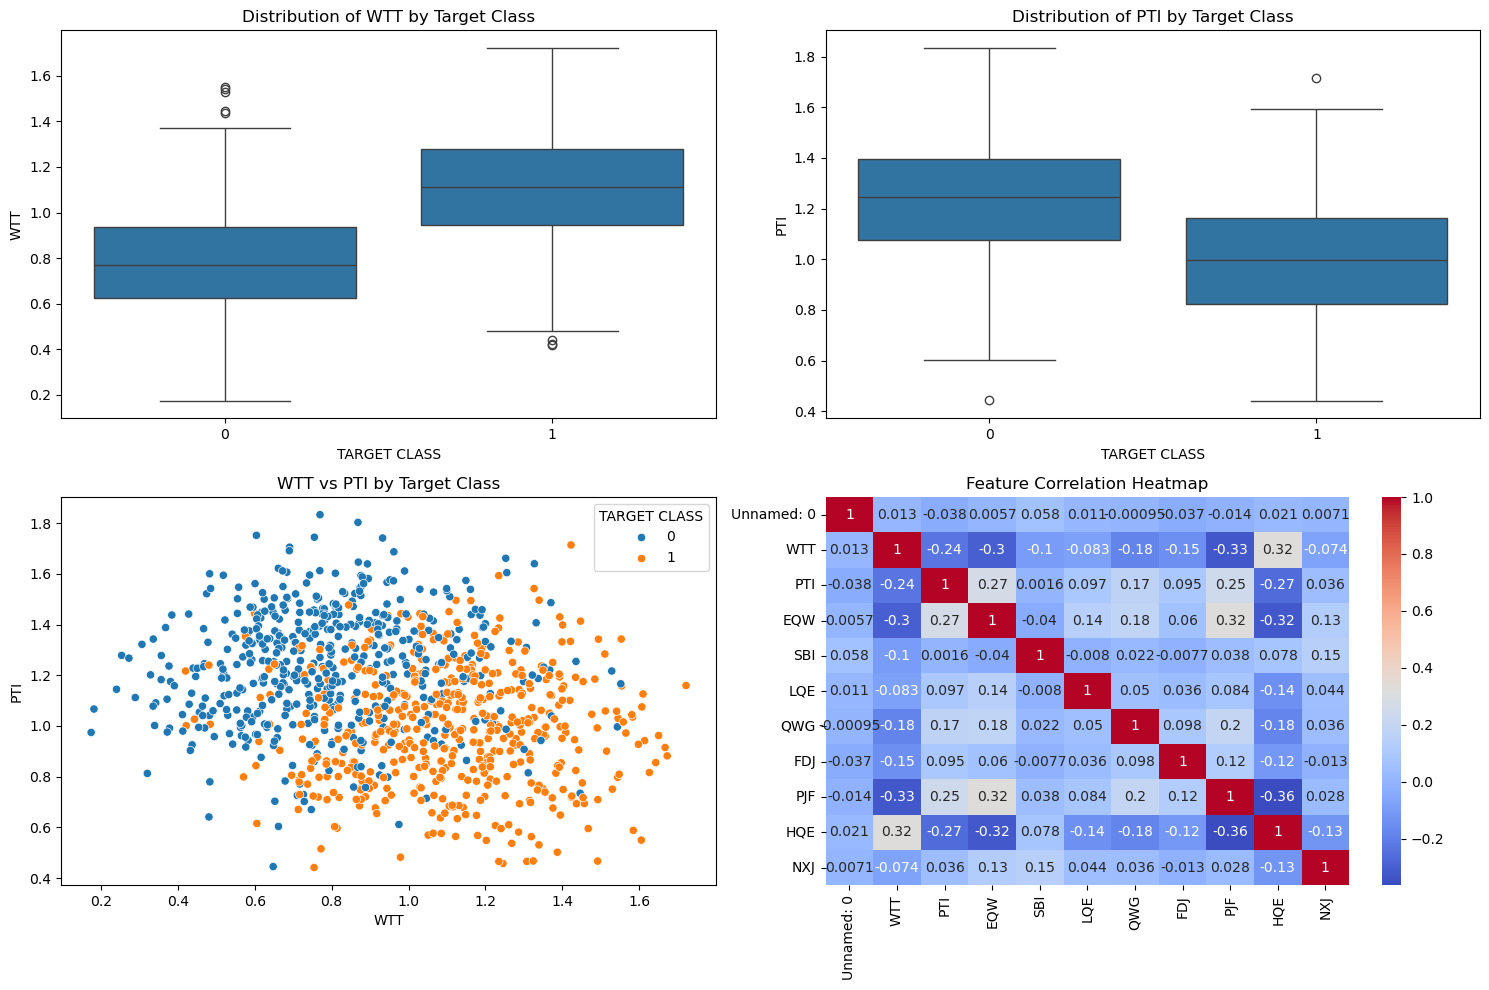

In [5]:
# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Distribution of WTT by TARGET CLASS
sns.boxplot(x='TARGET CLASS', y='WTT', data=df, ax=axes[0,0])
axes[0,0].set_title('Distribution of WTT by Target Class')

# Plot 2: Distribution of PTI by TARGET CLASS
sns.boxplot(x='TARGET CLASS', y='PTI', data=df, ax=axes[0,1])
axes[0,1].set_title('Distribution of PTI by Target Class')

# Plot 3: Scatter plot of WTT vs PTI colored by TARGET CLASS
sns.scatterplot(x='WTT', y='PTI', hue='TARGET CLASS', data=df, ax=axes[1,0])
axes[1,0].set_title('WTT vs PTI by Target Class')

# Plot 4: Correlation heatmap of features
correlation_matrix = df.drop('TARGET CLASS', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## 3. Data Preparation
Now we'll prepare our data for modeling by:
1. Separating features and target variables
2. Scaling the features
3. Splitting the data into training and testing sets

In [6]:
# Separate features (X) and target variable (y)
X = df.drop('TARGET CLASS', axis=1)
y = df['TARGET CLASS']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (700, 11)
Testing set shape: (300, 11)


## 4. Model Training
We'll train a K-Nearest Neighbors classifier and find the best value for k using cross-validation.

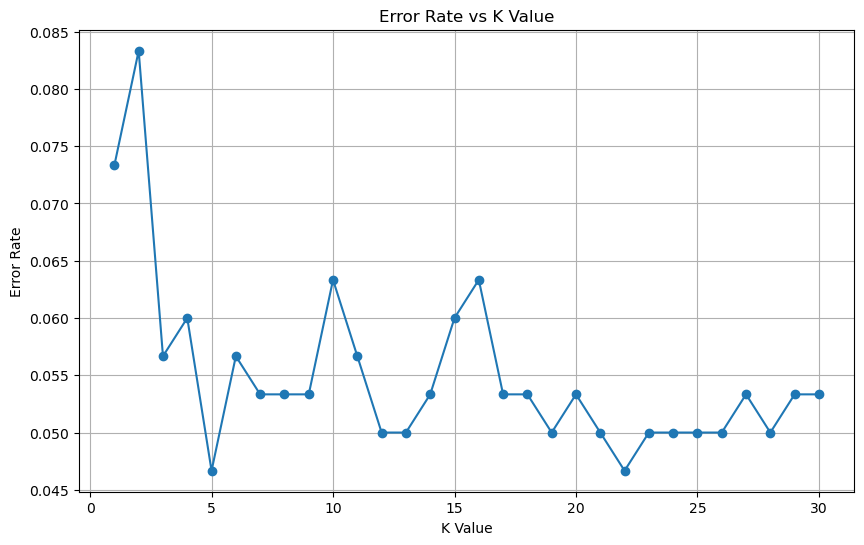

Best k value: 5


KNeighborsClassifier()

In [7]:
# Let's try different values of k and find the best one
error_rates = []
k_values = range(1, 31)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rates.append(np.mean(pred_k != y_test))

# Plot error rates for different k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates, marker='o')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Error Rate vs K Value')
plt.grid(True)
plt.show()

# Find the best k value
best_k = k_values[np.argmin(error_rates)]
print(f"Best k value: {best_k}")

# Train the final model with the best k value
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

## 5. Model Evaluation
Let's evaluate our model's performance using various metrics:

Model Performance Metrics:

Accuracy Score: 0.9533333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       142
           1       0.96      0.95      0.96       158

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



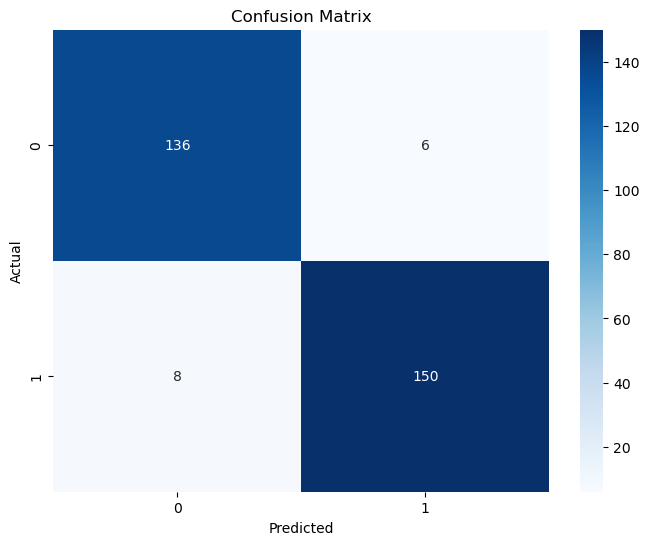

In [8]:
# Make predictions on the test set
y_pred = final_knn.predict(X_test)

# Calculate and display various metrics
print("Model Performance Metrics:\n")
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Create and plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Making Predictions
Let's demonstrate how to use our trained model to make predictions on new data.

In [9]:
# Example of making predictions on new data
# Let's take a few samples from our test set to demonstrate
sample_data = X_test[:3]  # Taking first 3 samples

# Make predictions
predictions = final_knn.predict(sample_data)
probabilities = final_knn.predict_proba(sample_data)

# Display results
print("Predictions for 3 sample points:")
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    print(f"\nSample {i+1}:")
    print(f"Predicted class: {pred}")
    print(f"Probability of class 0: {prob[0]:.3f}")
    print(f"Probability of class 1: {prob[1]:.3f}")

print("\nActual values for these samples:")
print(y_test[:3].values)

Predictions for 3 sample points:

Sample 1:
Predicted class: 0
Probability of class 0: 1.000
Probability of class 1: 0.000

Sample 2:
Predicted class: 1
Probability of class 0: 0.000
Probability of class 1: 1.000

Sample 3:
Predicted class: 1
Probability of class 0: 0.000
Probability of class 1: 1.000

Actual values for these samples:
[0 1 1]


## Conclusion

In this notebook, we:
1. Successfully implemented a K-Nearest Neighbors classifier
2. Found the optimal k value (k=5) through cross-validation
3. Achieved a high accuracy of 95.33% on the test set
4. Created a model that shows good balance between precision and recall for both classes

The confusion matrix and classification report show that our model performs well for both classes, with very few misclassifications. The model can be reliably used for making predictions on new data points.